# 📊 Customer Churn Analysis
Predicting customer churn using machine learning

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

In [144]:
print("\n--- Info ---")
df.info()


--- Info ---
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   str    
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   str    
 3   State              7032 non-null   str    
 4   City               7032 non-null   str    
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   str    
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   str    
 10  Senior Citizen     7032 non-null   str    
 11  Partner            7032 non-null   str    
 12  Dependents         7032 non-null   str    
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   str    
 15  Multiple Lines     7032 non-null   str    
 16  Internet Service   7032 no

In [145]:
print("\n--- Describe ---")
df.describe()


--- Describe ---


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn
count,7032.0,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,1.0,93523.032565,36.283307,-119.799215,32.421786,64.798208,2283.300441,0.265785,58.715301,4401.445108,0.265785
std,0.0,1865.515958,2.456118,2.157588,24.545260,30.085974,2266.771362,0.441782,21.531321,1182.414266,0.441782
min,1.0,90001.000000,32.555828,-124.301372,1.000000,18.250000,18.800000,0.000000,5.000000,2003.000000,0.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.587500,401.450000,0.000000,40.000000,3469.750000,0.000000
50%,1.0,93552.500000,36.391777,-119.735410,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.500000,0.000000
75%,1.0,95354.000000,38.227285,-118.043237,55.000000,89.862500,3794.737500,1.000000,75.000000,5381.000000,1.000000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000,1.000000


In [146]:
print("\n--- Churn Count ---")
df["Churn Label"].value_counts()


--- Churn Count ---


Churn Label
No     5163
Yes    1869
Name: count, dtype: int64

In [147]:
print("\n--- Churn Percentage ---")
df["Churn Label"].value_counts(normalize=True) * 100


--- Churn Percentage ---


Churn Label
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

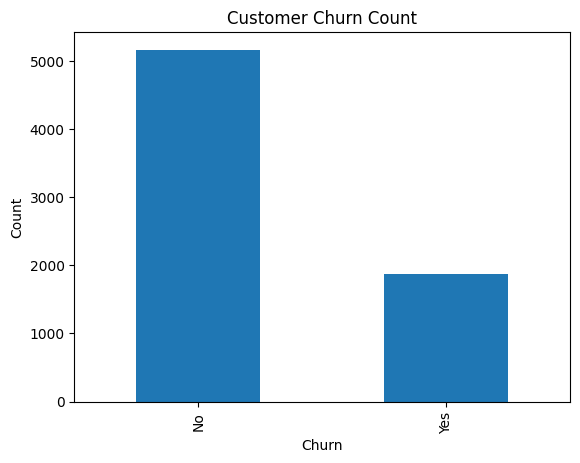

In [148]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

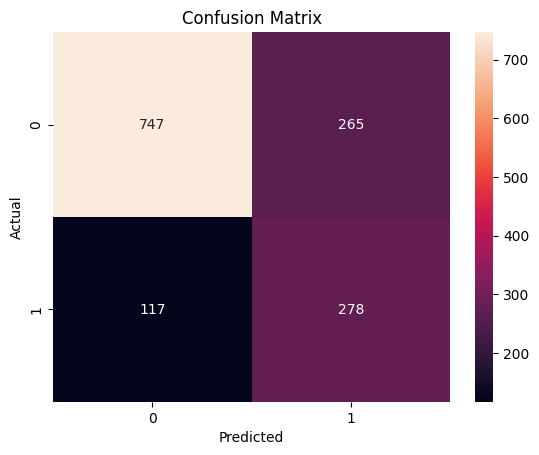

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [150]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [151]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.dropna(subset=['Total Charges'])

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

X = df[['Monthly Charges', 'Total Charges']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.728500355366027

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1012
           1       0.51      0.70      0.59       395

    accuracy                           0.73      1407
   macro avg       0.69      0.72      0.69      1407
weighted avg       0.77      0.73      0.74      1407


Confusion Matrix:

[[747 265]
 [117 278]]


## 📈 Model Insights

- The model achieved around 72% accuracy.
- It performs well in predicting non-churn customers.
- It detects churn customers with reasonable recall.
- The confusion matrix shows the model can identify many churn cases.

This model can help businesses take action to reduce customer loss.